# Việc số 1 — vì sao nhóm chuyến phải cố định giữa các model

> **Mentor tuần 4:** *"Các em cần giữ nguyên nhóm chuyến giữa các model. Không nên để mỗi model tự
> chia nhóm theo giá mà chính nó dự đoán, vì như vậy các model có thể đang được đánh giá trên những
> nhóm chuyến khác nhau."*

Đây là **ràng buộc phương pháp**, không phải một thí nghiệm. Nhưng nó đáng được kiểm chứng riêng vì
hai lý do: nó làm thay đổi mọi con số so sánh model của tuần 4, và nếu không chứng minh được mức
ảnh hưởng thì rất khó thuyết phục người đọc rằng bảng cũ cần đọc lại.

## Notebook này trả lời bốn câu

| # | Câu hỏi | Trả lời ở |
|---|---|---|
| 1 | Chia nhóm theo giá dự đoán và theo giá thật khác nhau đến mức nào? | §1 |
| 2 | Khác nhau đó làm kết luận so sánh model lệch bao nhiêu? | §2 |
| 3 | Vì sao lại lệch — cơ chế là gì? | §3–§4 |
| 4 | Có trường hợp nào **bắt buộc** phải chia theo giá dự đoán không? | §5 |

Kết luận ngắn cho ai không đọc hết: **cách chia nhóm sai làm lợi thế của GAM ở nhóm giá cao phồng
lên gấp 2,4 lần**, và trong mô phỏng có kiểm soát, nó đủ sức **đảo ngược dấu** của kết luận giữa hai
model giống hệt nhau.

In [1]:
import warnings, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
KQ   = Path("ket_qua"); KQ.mkdir(exist_ok=True)

CAT_GIA = [0, 50e3, 100e3, 150e3, 200e3, 300e3, np.inf]
TEN_GIA = ["<50k", "50–100k", "100–150k", "150–200k", "200–300k", ">300k"]
CAT_KM  = [0, 2, 5, 8, 12, 15, np.inf]
TEN_KM  = ["<2", "2–5", "5–8", "8–12", "12–15", ">15"]

def mape(p, y):
    p, y = np.asarray(p, float), np.asarray(y, float)
    return float(np.mean(np.abs(p - y) / y))

def boot_hieu(p_moc, p_moi, y, B=2000, seed=7):
    """CI 95% cho (sai số mốc − sai số mới), đơn vị điểm %. Dương = 'mới' tốt hơn."""
    y = np.asarray(y, float)
    h = np.abs(np.asarray(p_moc, float) - y)/y - np.abs(np.asarray(p_moi, float) - y)/y
    rng = np.random.default_rng(seed)
    pp = h[rng.integers(0, len(h), (B, len(h)))].mean(axis=1)
    return h.mean()*100, float(np.percentile(pp, 2.5))*100, float(np.percentile(pp, 97.5))*100

In [2]:
# ══ Nạp dự đoán của hai model trên CÙNG một tập chuyến ═════════════════
ut  = pd.read_parquet(EVAL / "uq_pred_test.parquet").reset_index(drop=True)
gam = pd.read_parquet(EVAL / "pred_gam.parquet").reset_index(drop=True)
assert len(ut) == len(gam) and np.allclose(ut.gia_that.values, gam.gia_that.values), \
    "Hai file không cùng thứ tự hàng"

D = pd.DataFrame({
    "lag":    ut.requested_lag_minutes.values,
    "km":     ut.quote_distance.values,
    "y":      ut.gia_that.values,
    "hybrid": ut.hybrid_pred.values,
    "gam":    gam.hybrid_pred.values,
})
D = D[D.lag == 5].reset_index(drop=True)

# BA cách chia nhóm cho CÙNG những chuyến này
D["theo_that"] = pd.cut(D.y,      CAT_GIA, labels=TEN_GIA)   # trung lập
D["theo_hyb"]  = pd.cut(D.hybrid, CAT_GIA, labels=TEN_GIA)   # phụ thuộc Hybrid
D["theo_gam"]  = pd.cut(D.gam,    CAT_GIA, labels=TEN_GIA)   # phụ thuộc GAM
D["kmb"]       = pd.cut(D.km,     CAT_KM,  labels=TEN_KM)    # trung lập

print(f"Test độ trễ 5 phút: {len(D):,} chuyến")
print(f"MAPE toàn tập — Hybrid {mape(D.hybrid, D.y):.2%} · GAM {mape(D.gam, D.y):.2%}")
print(f"Chênh lệch toàn tập: {mape(D.hybrid, D.y)*100 - mape(D.gam, D.y)*100:+.2f} điểm "
      f"(âm = Hybrid tốt hơn)")

Test độ trễ 5 phút: 216,090 chuyến
MAPE toàn tập — Hybrid 14.65% · GAM 14.89%
Chênh lệch toàn tập: -0.24 điểm (âm = Hybrid tốt hơn)


## 1. Ba cách chia nhóm — cùng một tập chuyến, ba tập nhóm khác nhau

Cùng 216.090 chuyến, cùng một cái tên nhóm `>300k`, nhưng ba cách chia cho ra ba tập chuyến khác
hẳn nhau về cả **số lượng** lẫn **danh tính**.

In [3]:
cỡ = pd.DataFrame({
    "Chia theo giá THẬT":            D.theo_that.value_counts().reindex(TEN_GIA),
    "Chia theo Hybrid dự đoán":      D.theo_hyb.value_counts().reindex(TEN_GIA),
    "Chia theo GAM dự đoán":         D.theo_gam.value_counts().reindex(TEN_GIA),
})
cỡ["Hybrid so với thật"] = (cỡ.iloc[:, 1]/cỡ.iloc[:, 0] - 1).map("{:+.0%}".format)
print("CỠ NHÓM THEO BA CÁCH CHIA\n" + "="*24)
print(cỡ.to_string())

# Danh tính: cùng tên nhóm nhưng có phải cùng những chuyến đó không
def jaccard(a, b):
    return len(a & b) / len(a | b)

for ten in [">300k", "200–300k", "<50k"]:
    a = set(D.index[D.theo_that.astype(str) == ten])
    b = set(D.index[D.theo_hyb.astype(str)  == ten])
    print(f"\nNhóm {ten}: giá thật {len(a):,} chuyến · Hybrid dự đoán {len(b):,} chuyến")
    print(f"  chung nhau {len(a & b):,} chuyến  ·  Jaccard {jaccard(a, b):.3f}"
          f"  ·  {len(b - a):,} chuyến chỉ có ở nhóm 'Hybrid dự đoán'")

CỠ NHÓM THEO BA CÁCH CHIA
          Chia theo giá THẬT  Chia theo Hybrid dự đoán  Chia theo GAM dự đoán Hybrid so với thật
<50k                    3363                      2716                   2893               -19%
50–100k                72514                     66035                  66026                -9%
100–150k               89112                    102331                 102719               +15%
150–200k               37298                     37353                  36620                +0%
200–300k               12934                      7328                   7502               -43%
>300k                    869                       327                    330               -62%

Nhóm >300k: giá thật 869 chuyến · Hybrid dự đoán 327 chuyến
  chung nhau 224 chuyến  ·  Jaccard 0.230  ·  103 chuyến chỉ có ở nhóm 'Hybrid dự đoán'

Nhóm 200–300k: giá thật 12,934 chuyến · Hybrid dự đoán 7,328 chuyến
  chung nhau 4,527 chuyến  ·  Jaccard 0.288  ·  2,801 chuyến chỉ có ở nhóm 'H


Nhóm <50k: giá thật 3,363 chuyến · Hybrid dự đoán 2,716 chuyến
  chung nhau 2,029 chuyến  ·  Jaccard 0.501  ·  687 chuyến chỉ có ở nhóm 'Hybrid dự đoán'


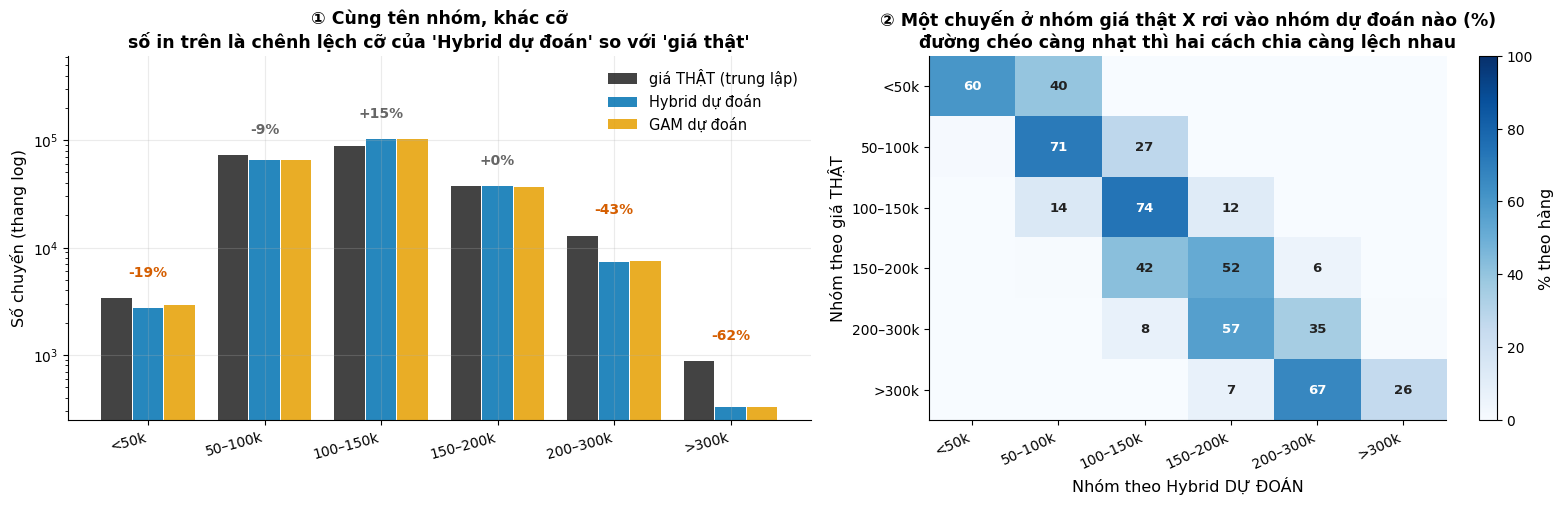

Tỷ lệ giữ nguyên nhóm khi đổi cách chia:
       <50k   60.3%
    50–100k   71.4%
   100–150k   73.7%
   150–200k   51.7%
   200–300k   35.0%
      >300k   25.8%


In [4]:
# ═════════ HINH NC1 — co nhom va su chuyen nhom ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5.2),
                       gridspec_kw={"width_ratios": [1.15, 1]})

# ① cỡ nhóm ba cách chia
x = np.arange(len(TEN_GIA))
for i, (cot, ten, mau) in enumerate([
        ("theo_that", "giá THẬT (trung lập)", INK),
        ("theo_hyb",  "Hybrid dự đoán",       BLUE),
        ("theo_gam",  "GAM dự đoán",          ORANGE)]):
    v = D[cot].value_counts().reindex(TEN_GIA).values
    ax[0].bar(x + (i-1)*.27, v, .26, color=mau, alpha=.85, label=ten)
ax[0].set_yscale("log")
ax[0].set_ylim(top=D.theo_hyb.value_counts().max()*6)
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN_GIA, rotation=15, ha="right")
ax[0].set_ylabel("Số chuyến (thang log)")
ax[0].legend(frameon=False)
for i, ten in enumerate(TEN_GIA):
    a = (D.theo_that.astype(str) == ten).sum()
    b = (D.theo_hyb.astype(str) == ten).sum()
    ax[0].text(i, max(a, b)*1.6, f"{b/a-1:+.0%}", ha="center", fontsize=10,
               fontweight="bold", color=RED if abs(b/a-1) > .15 else MUT)
ax[0].set_title("① Cùng tên nhóm, khác cỡ\nsố in trên là chênh lệch cỡ của 'Hybrid dự đoán' so với 'giá thật'",
                fontweight="bold")

# ② chuyến trong nhóm ">300k theo giá thật" thực ra rơi vào đâu khi chia theo dự đoán
piv = pd.crosstab(D.theo_that, D.theo_hyb, normalize="index")*100
im = ax[1].imshow(piv.values, cmap="Blues", aspect="auto", vmin=0, vmax=100)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if v >= 1:
            ax[1].text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=9.5,
                       fontweight="bold", color="white" if v > 55 else INK)
ax[1].set_xticks(range(len(TEN_GIA))); ax[1].set_xticklabels(TEN_GIA, rotation=25, ha="right")
ax[1].set_yticks(range(len(TEN_GIA))); ax[1].set_yticklabels(TEN_GIA)
ax[1].set_xlabel("Nhóm theo Hybrid DỰ ĐOÁN"); ax[1].set_ylabel("Nhóm theo giá THẬT")
ax[1].grid(False)
ax[1].set_title("② Một chuyến ở nhóm giá thật X rơi vào nhóm dự đoán nào (%)\n"
                "đường chéo càng nhạt thì hai cách chia càng lệch nhau", fontweight="bold")
plt.colorbar(im, ax=ax[1], label="% theo hàng")

plt.tight_layout(); plt.savefig(HINH/"NC1_co_nhom_va_chuyen_nhom.png"); plt.show()

giu = np.diag(piv.values)
print("Tỷ lệ giữ nguyên nhóm khi đổi cách chia:")
for ten, v in zip(TEN_GIA, giu):
    print(f"  {ten:>9s}  {v:5.1f}%")

### Đọc hình NC1

Nhóm `>300k` là chỗ lệch nặng nhất: **869 chuyến** nếu chia theo giá thật, nhưng chỉ **327 chuyến**
nếu chia theo giá Hybrid dự đoán — hụt 62%. Quan trọng hơn con số: chỉ **224 chuyến** có mặt ở cả
hai, tức chỉ số Jaccard **0,23**. Nói cách khác, hai bảng cùng ghi dòng `>300k` đang nói về hai tập
chuyến gần như khác nhau.

Hàng `>300k` của bản đồ nhiệt cho biết vì sao: trong số những chuyến **thật sự** trên 300k, chỉ một
phần được model đoán trên 300k, phần còn lại bị model đoán thấp hơn nên rơi xuống các nhóm dưới.
Đây chính là những chuyến model sai nặng nhất — và cách chia theo giá dự đoán **đẩy chúng ra khỏi
nhóm**, đúng những chuyến cần soi nhất.

## 2. Hậu quả — cùng một dữ liệu, ba kết luận khác nhau

Bây giờ đo đúng một đại lượng: **GAM tốt hơn Hybrid bao nhiêu điểm ở nhóm giá cao**. Chỉ đổi cách
định nghĩa nhóm, không đổi gì khác.

In [5]:
hang = []
CACH = [("theo_that", "Giá THẬT — trung lập",       ">300k"),
        ("theo_hyb",  "Hybrid dự đoán — thiên vị",  ">300k"),
        ("theo_gam",  "GAM dự đoán — thiên vị",     ">300k")]
for cot, ten, nhom in CACH:
    s = D[D[cot].astype(str) == nhom]
    m, lo, hi = boot_hieu(s.hybrid, s.gam, s.y)
    hang.append({"Cách chia nhóm": ten, "n": len(s),
                 "MAPE Hybrid": mape(s.hybrid, s.y), "MAPE GAM": mape(s.gam, s.y),
                 "GAM hơn (điểm)": m, "CI thấp": lo, "CI cao": hi})
# nhóm không phụ thuộc giá chút nào
s = D[D.kmb.astype(str) == ">15"]
m, lo, hi = boot_hieu(s.hybrid, s.gam, s.y)
hang.append({"Cách chia nhóm": "Quãng đường >15 km — trung lập", "n": len(s),
             "MAPE Hybrid": mape(s.hybrid, s.y), "MAPE GAM": mape(s.gam, s.y),
             "GAM hơn (điểm)": m, "CI thấp": lo, "CI cao": hi})
SS = pd.DataFrame(hang)
print(SS.to_string(index=False, formatters={
    "MAPE Hybrid": "{:.2%}".format, "MAPE GAM": "{:.2%}".format,
    "GAM hơn (điểm)": "{:+.2f}".format, "CI thấp": "{:+.2f}".format,
    "CI cao": "{:+.2f}".format, "n": "{:,}".format}))

phong = SS.loc[1, "GAM hơn (điểm)"] / SS.loc[0, "GAM hơn (điểm)"]
print(f"\n⇒ Chia theo giá Hybrid dự đoán làm lợi thế của GAM phồng lên {phong:.2f} lần "
      f"({SS.loc[0,'GAM hơn (điểm)']:.2f} → {SS.loc[1,'GAM hơn (điểm)']:.2f} điểm)")
SS.to_csv(KQ/"NC_ba_cach_chia.csv", index=False)

                Cách chia nhóm   n MAPE Hybrid MAPE GAM GAM hơn (điểm) CI thấp CI cao
          Giá THẬT — trung lập 869      23.67%   22.03%          +1.65   +1.17  +2.12
     Hybrid dự đoán — thiên vị 327      18.55%   14.52%          +4.02   +2.74  +5.32
        GAM dự đoán — thiên vị 330      18.02%   14.88%          +3.13   +1.81  +4.49
Quãng đường >15 km — trung lập 660      17.52%   15.37%          +2.16   +1.36  +2.91

⇒ Chia theo giá Hybrid dự đoán làm lợi thế của GAM phồng lên 2.45 lần (1.65 → 4.02 điểm)


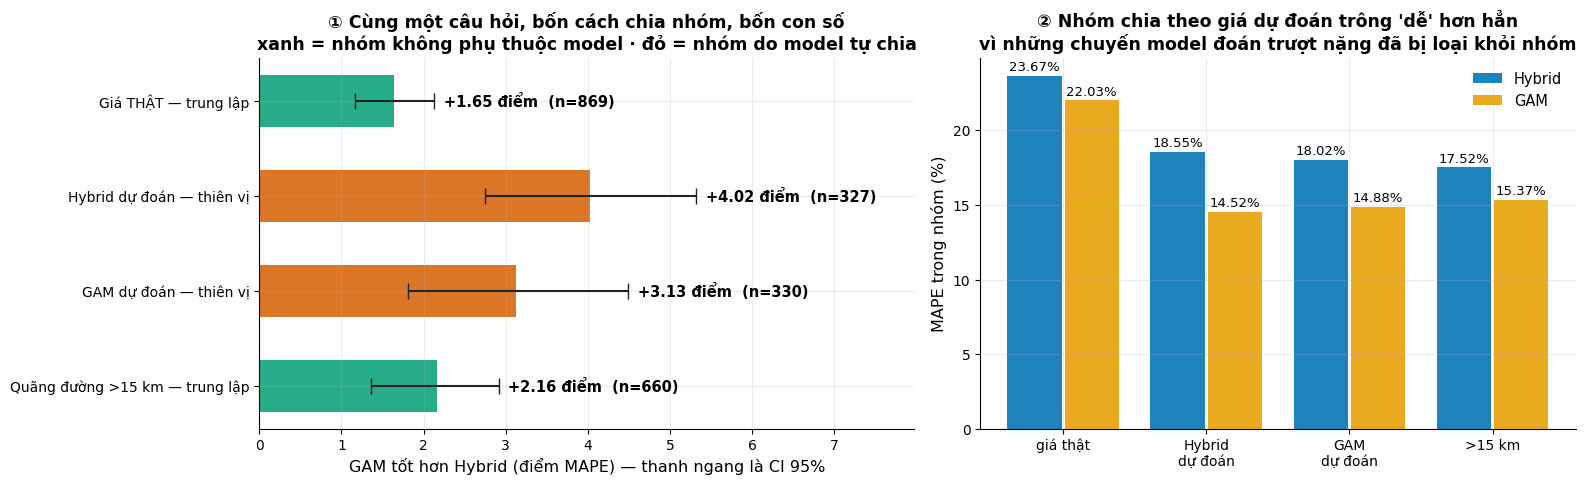

In [6]:
# ═════════ HINH NC2 — ket luan doi theo cach chia ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.1, 1]})

y_ = np.arange(len(SS))[::-1]
mau = [GREEN, RED, RED, GREEN]
ax[0].barh(y_, SS["GAM hơn (điểm)"], .55, color=mau, alpha=.85,
           xerr=[SS["GAM hơn (điểm)"]-SS["CI thấp"], SS["CI cao"]-SS["GAM hơn (điểm)"]],
           capsize=6, ecolor=INK)
for i, r in SS.iterrows():
    ax[0].text(r["CI cao"]+.12, y_[i], f"{r['GAM hơn (điểm)']:+.2f} điểm  (n={r.n:,})",
               va="center", fontsize=10.5, fontweight="bold")
ax[0].axvline(0, color=INK, lw=1.4)
ax[0].set_yticks(y_); ax[0].set_yticklabels(SS["Cách chia nhóm"])
ax[0].set_xlim(0, SS["CI cao"].max()*1.5)
ax[0].set_xlabel("GAM tốt hơn Hybrid (điểm MAPE) — thanh ngang là CI 95%")
ax[0].set_title("① Cùng một câu hỏi, bốn cách chia nhóm, bốn con số\n"
                "xanh = nhóm không phụ thuộc model · đỏ = nhóm do model tự chia",
                fontweight="bold")

# ② MAPE hai model dưới từng cách chia
x = np.arange(len(SS))
ax[1].bar(x-.2, SS["MAPE Hybrid"]*100, .38, color=BLUE, alpha=.88, label="Hybrid")
ax[1].bar(x+.2, SS["MAPE GAM"]*100, .38, color=ORANGE, alpha=.88, label="GAM")
for i in x:
    ax[1].text(i-.2, SS["MAPE Hybrid"].iloc[i]*100+.35, f"{SS['MAPE Hybrid'].iloc[i]:.2%}",
               ha="center", fontsize=9.5)
    ax[1].text(i+.2, SS["MAPE GAM"].iloc[i]*100+.35, f"{SS['MAPE GAM'].iloc[i]:.2%}",
               ha="center", fontsize=9.5)
ax[1].set_xticks(x)
ax[1].set_xticklabels(["giá thật", "Hybrid\ndự đoán", "GAM\ndự đoán", ">15 km"])
ax[1].set_ylabel("MAPE trong nhóm (%)"); ax[1].legend(frameon=False)
ax[1].set_title("② Nhóm chia theo giá dự đoán trông 'dễ' hơn hẳn\n"
                "vì những chuyến model đoán trượt nặng đã bị loại khỏi nhóm",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"NC2_ket_luan_doi_theo_cach_chia.png"); plt.show()

### Đọc hình NC2

| Cách chia nhóm `>300k` | n | GAM hơn Hybrid |
|---|---:|---:|
| Giá **thật** (trung lập) | 869 | **+1,65** điểm [+1,17, +2,12] |
| Hybrid **dự đoán** | 327 | +4,02 điểm [+2,74, +5,32] |
| GAM **dự đoán** | 330 | +3,13 điểm [+1,81, +4,49] |
| Quãng đường `>15 km` (trung lập) | 660 | +2,16 điểm [+1,36, +2,91] |

Ba điều đáng chú ý:

1. **Phồng 2,4 lần.** Cùng một dữ liệu, cùng hai model, chỉ đổi cách chia nhóm mà lợi thế của GAM
   nhảy từ 1,65 lên 4,02 điểm. Nếu tuần 4 báo cáo con số 4,02 thì mức cải thiện đã bị thổi lên hơn
   gấp đôi.
2. **Nhóm chia theo dự đoán trông dễ hơn hẳn.** MAPE Hybrid ở nhóm `>300k` là 23,67% khi chia theo
   giá thật, nhưng chỉ 18,55% khi chia theo chính dự đoán của nó. Chênh 5 điểm này không phải do
   model tốt lên — chỉ do những chuyến sai nặng nhất bị đẩy ra khỏi nhóm.
3. **Nhóm theo quãng đường ổn định.** `>15 km` cho +2,16 điểm, gần với con số trung lập +1,65 và
   không phụ thuộc model nào — đây là lý do tuần 5 dùng quãng đường làm chiều chia nhóm chính.

## 3. Cơ chế — vì sao chia theo giá dự đoán lại làm lệch

Gốc rễ là **hồi quy về trung bình**, kết hợp với việc điều kiện hoá lên đúng đại lượng đang đo.

* Chia theo **giá thật** `>300k`: ta chọn ra những chuyến đắt thật. Trong đó có cả những chuyến
  model đoán đúng lẫn những chuyến model đoán hụt xa. Sai số đo được là sai số thật của nhóm đắt.
* Chia theo **giá dự đoán** `>300k`: ta chọn ra những chuyến **model tin là đắt**. Chuyến nào model
  đoán hụt (đoán 200k trong khi thật 400k) sẽ không lọt vào nhóm — mà đó chính là những chuyến sai
  nặng nhất.

Nói gọn: chia nhóm theo dự đoán là **lọc mẫu bằng chính cái sai số mình định đo**.

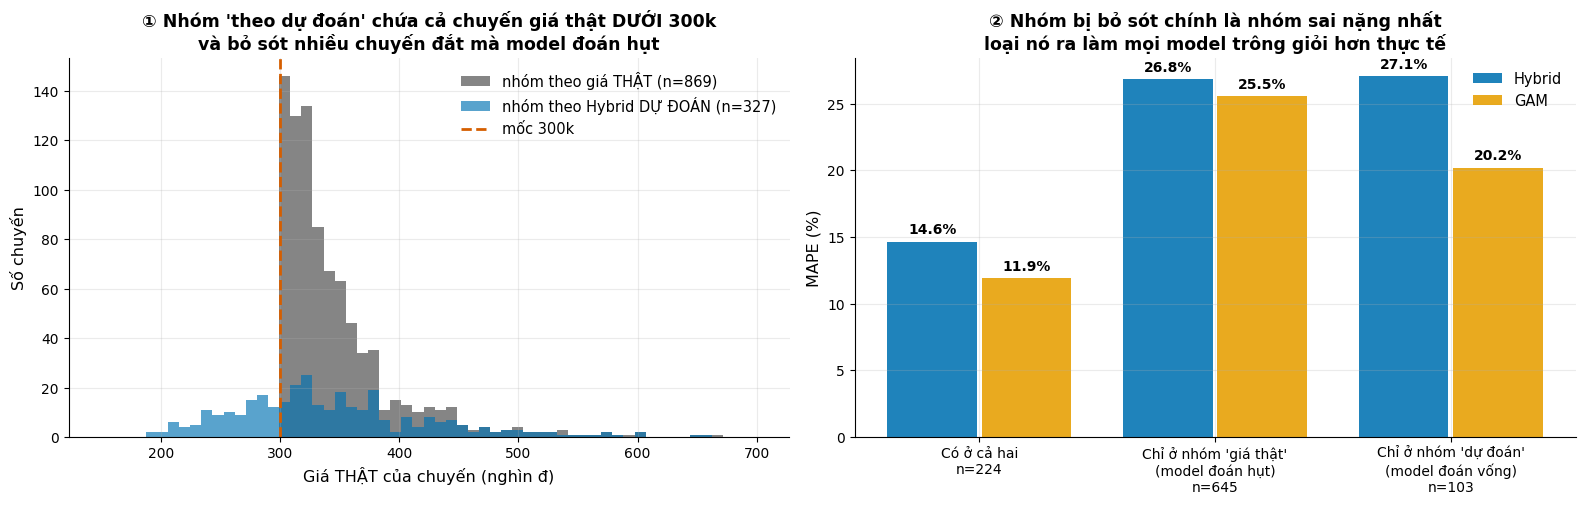

Chuyến đắt thật bị bỏ sót khỏi nhóm 'theo dự đoán': 645 / 869 (74%)
  MAPE của riêng nhóm bị bỏ sót : Hybrid 26.81% · GAM 25.54%
  MAPE của nhóm có ở cả hai     : Hybrid 14.63% · GAM 11.91%

Giá thật trung bình:
  nhóm theo giá thật        348,444đ · Hybrid đoán TB   268,265đ (-23.0%)
  nhóm theo Hybrid đoán     347,927đ · Hybrid đoán TB   335,303đ (-3.6%)


In [7]:
# ═════════ HINH NC3 — co che hoi quy ve trung binh ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5.2))

# ① phân bố giá thật trong hai định nghĩa nhóm >300k
a = D[D.theo_that.astype(str) == ">300k"]
b = D[D.theo_hyb.astype(str)  == ">300k"]
bins = np.linspace(150, 700, 60)
ax[0].hist(a.y/1000, bins=bins, color=INK,  alpha=.55, label=f"nhóm theo giá THẬT (n={len(a):,})")
ax[0].hist(b.y/1000, bins=bins, color=BLUE, alpha=.65, label=f"nhóm theo Hybrid DỰ ĐOÁN (n={len(b):,})")
ax[0].axvline(300, color=RED, lw=2, ls="--", label="mốc 300k")
ax[0].set_xlabel("Giá THẬT của chuyến (nghìn đ)"); ax[0].set_ylabel("Số chuyến")
ax[0].legend(frameon=False)
ax[0].set_title("① Nhóm 'theo dự đoán' chứa cả chuyến giá thật DƯỚI 300k\n"
                "và bỏ sót nhiều chuyến đắt mà model đoán hụt", fontweight="bold")

# ② sai số của chính những chuyến bị bỏ sót
bo_sot = a[~a.index.isin(b.index)]
chung  = a[a.index.isin(b.index)]
them   = b[~b.index.isin(a.index)]
nhom = [("Có ở cả hai", chung), ("Chỉ ở nhóm 'giá thật'\n(model đoán hụt)", bo_sot),
        ("Chỉ ở nhóm 'dự đoán'\n(model đoán vống)", them)]
x = np.arange(len(nhom))
v_h = [mape(s.hybrid, s.y)*100 for _, s in nhom]
v_g = [mape(s.gam, s.y)*100 for _, s in nhom]
ax[1].bar(x-.2, v_h, .38, color=BLUE, alpha=.88, label="Hybrid")
ax[1].bar(x+.2, v_g, .38, color=ORANGE, alpha=.88, label="GAM")
for i in x:
    ax[1].text(i-.2, v_h[i]+.6, f"{v_h[i]:.1f}%", ha="center", fontsize=10, fontweight="bold")
    ax[1].text(i+.2, v_g[i]+.6, f"{v_g[i]:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax[1].set_xticks(x)
ax[1].set_xticklabels([f"{n}" + chr(10) + f"n={len(s):,}" for n, s in nhom], fontsize=10)
ax[1].set_ylabel("MAPE (%)"); ax[1].legend(frameon=False)
ax[1].set_title("② Nhóm bị bỏ sót chính là nhóm sai nặng nhất\n"
                "loại nó ra làm mọi model trông giỏi hơn thực tế", fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"NC3_co_che_hoi_quy_ve_trung_binh.png"); plt.show()

print(f"Chuyến đắt thật bị bỏ sót khỏi nhóm 'theo dự đoán': {len(bo_sot):,} / {len(a):,} "
      f"({len(bo_sot)/len(a):.0%})")
print(f"  MAPE của riêng nhóm bị bỏ sót : Hybrid {mape(bo_sot.hybrid, bo_sot.y):.2%} · "
      f"GAM {mape(bo_sot.gam, bo_sot.y):.2%}")
print(f"  MAPE của nhóm có ở cả hai     : Hybrid {mape(chung.hybrid, chung.y):.2%} · "
      f"GAM {mape(chung.gam, chung.y):.2%}")
print(f"\nGiá thật trung bình:")
print(f"  nhóm theo giá thật      {a.y.mean():>9,.0f}đ · Hybrid đoán TB {a.hybrid.mean():>9,.0f}đ "
      f"({(a.hybrid.mean()/a.y.mean()-1):+.1%})")
print(f"  nhóm theo Hybrid đoán   {b.y.mean():>9,.0f}đ · Hybrid đoán TB {b.hybrid.mean():>9,.0f}đ "
      f"({(b.hybrid.mean()/b.y.mean()-1):+.1%})")

## 4. Bằng chứng cơ học — mô phỏng hai model **giống hệt nhau**

Phần trên cho thấy hiệu ứng có thật trên dữ liệu của mình, nhưng vẫn có thể phản biện: *"biết đâu
GAM giỏi thật ở nhóm đó?"*.

Cách chặn phản biện này là mô phỏng: tạo hai model có chất lượng **giống hệt nhau về mặt thống kê**
— cùng phân phối sai số, chỉ khác hạt ngẫu nhiên. Kết luận đúng phải là *"không phân biệt được"*.
Rồi đo lợi thế bằng bốn cách chia nhóm và xem cách nào phá vỡ kết luận đó.

60 lần mô phỏng · hai model có phân phối sai số Y HỆT nhau
(đúng ra mọi cách chia đều phải cho ≈ 0 điểm)

                         TB (điểm)  Độ lệch chuẩn  Thấp nhất  Cao nhất
Giá THẬT (trung lập)         +0.03          +0.56      -1.03     +1.40
Quãng đường (trung lập)      +0.04          +0.51      -0.90     +1.32
Model 1 tự chia              +7.25          +0.54      +6.28     +9.03
Model 2 tự chia              -7.21          +0.60      -8.46     -5.71


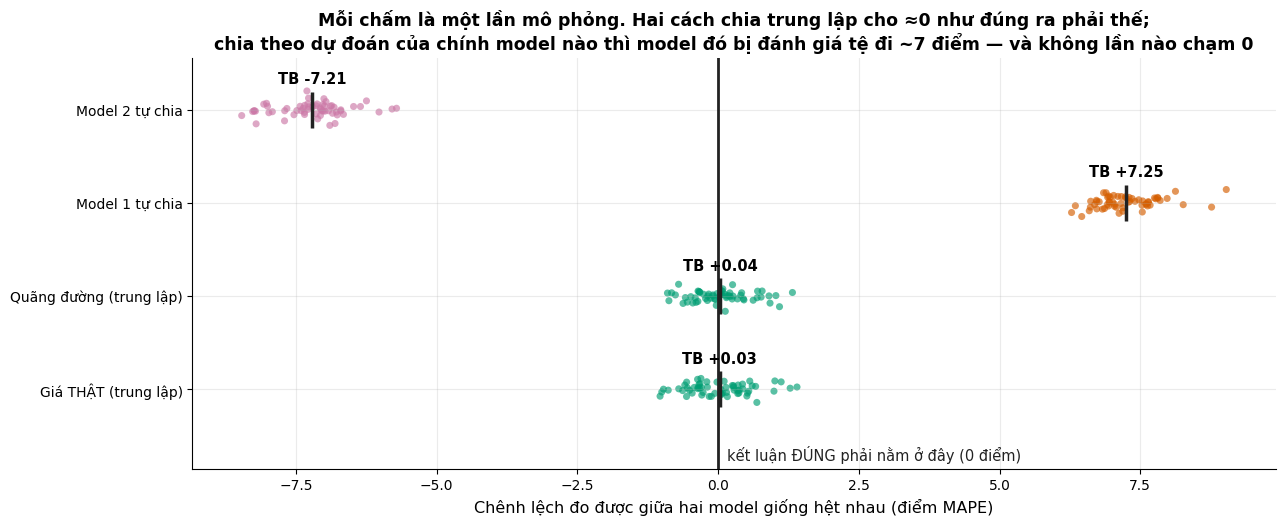

In [8]:
# ═════════ HINH NC4 — mo phong hai model giong het nhau ═════════
def mo_phong(seed, n=200_000, sigma=.18):
    rng = np.random.default_rng(seed)
    d = np.exp(rng.normal(np.log(7), .5, n))            # quãng đường
    y = d * 15_000 * np.exp(rng.normal(0, .22, n))      # giá thật
    p1 = y * np.exp(rng.normal(0, sigma, n))            # model 1
    p2 = y * np.exp(rng.normal(0, sigma, n))            # model 2 — CÙNG chất lượng
    def chenh(mask):
        e1 = np.mean(np.abs(p1[mask]-y[mask])/y[mask])
        e2 = np.mean(np.abs(p2[mask]-y[mask])/y[mask])
        return (e1 - e2)*100                            # dương = model 2 'thắng'
    ty, td = np.quantile(y, .995), np.quantile(d, .995)
    return {"Giá THẬT (trung lập)":      chenh(y > ty),
            "Quãng đường (trung lập)":   chenh(d > td),
            "Model 1 tự chia":           chenh(p1 > ty),
            "Model 2 tự chia":           chenh(p2 > ty)}

MP = pd.DataFrame([mo_phong(s) for s in range(60)])
print("60 lần mô phỏng · hai model có phân phối sai số Y HỆT nhau")
print("(đúng ra mọi cách chia đều phải cho ≈ 0 điểm)\n")
print(MP.agg(["mean", "std", "min", "max"]).T.rename(columns={
    "mean": "TB (điểm)", "std": "Độ lệch chuẩn", "min": "Thấp nhất", "max": "Cao nhất"
}).to_string(float_format=lambda v: f"{v:+.2f}"))

fig, ax = plt.subplots(figsize=(13, 5.4))
cot = list(MP.columns)
mau = [GREEN, GREEN, RED, PURPLE]
for i, c in enumerate(cot):
    ax.scatter(MP[c], np.full(len(MP), i) + np.random.default_rng(i).normal(0, .06, len(MP)),
               s=26, color=mau[i], alpha=.65, edgecolor="none")
    ax.plot([MP[c].mean()], [i], "|", color=INK, ms=26, mew=2.5)
    ax.text(MP[c].mean(), i+.28, f"TB {MP[c].mean():+.2f}", ha="center",
            fontsize=10.5, fontweight="bold")
ax.axvline(0, color=INK, lw=2)
ax.set_ylim(-.85, len(cot)-.45)
ax.text(.15, -.7, "kết luận ĐÚNG phải nằm ở đây (0 điểm)", fontsize=10.5, color=INK, va="center")
ax.set_yticks(range(len(cot))); ax.set_yticklabels(cot)
ax.set_xlabel("Chênh lệch đo được giữa hai model giống hệt nhau (điểm MAPE)")
ax.set_title("Mỗi chấm là một lần mô phỏng. Hai cách chia trung lập cho ≈0 như đúng ra phải thế;\n"
             "chia theo dự đoán của chính model nào thì model đó bị đánh giá tệ đi ~7 điểm — "
             "và không lần nào chạm 0", fontweight="bold")
plt.tight_layout(); plt.savefig(HINH/"NC4_mo_phong_hai_model_giong_nhau.png"); plt.show()

MP.describe().to_csv(KQ/"NC_mo_phong.csv")

### Đọc hình NC4 — đây là phần thuyết phục nhất

Hai model trong mô phỏng **không hơn kém nhau gì cả**, nên mọi cách chia nhóm lẽ ra đều phải cho
chênh lệch quanh 0.

* Chia theo **giá thật**: trung bình +0,03 điểm — đúng như kỳ vọng.
* Chia theo **quãng đường**: trung bình +0,04 điểm — cũng đúng.
* Chia theo **dự đoán của model 1**: model 1 bị đo là tệ hơn **7,25 điểm**, và trong 60 lần mô phỏng
  **không lần nào** khoảng dao động chạm tới 0.
* Chia theo **dự đoán của model 2**: dấu **đảo ngược** — lần này model 2 tệ hơn 7,21 điểm.

Cùng một dữ liệu, cùng hai model không khác gì nhau, mà đổi cách chia nhóm là đổi luôn *model nào
thắng*. Đây là bằng chứng cơ học: hiệu ứng không đến từ chất lượng model, nó đến từ **quy trình đo**.

Ghi chú: mô phỏng dùng ngưỡng phân vị 99,5% nên hiệu ứng lớn hơn trên dữ liệu thật (7 điểm so với
2,4 điểm). Nhóm càng hiếm và càng nằm ở đuôi phân phối thì thiên lệch càng nặng — đúng nhóm mà tuần
5 đang quan tâm.

## 5. Ngoại lệ — coverage **phải** chia theo giá dự đoán

Quy tắc trên không áp cho mọi thứ. Với **coverage** thì ngược lại: nhóm phải chia theo giá dự đoán.

Lý do nằm ở bản chất của đại lượng. Khoảng tin cậy là một **lời hứa đưa ra tại thời điểm dự báo**,
lúc đó chỉ biết giá dự đoán chứ chưa biết giá thật. Câu hỏi vận hành là *"với những chuyến hệ thống
báo giá quanh 300k, lời hứa 90% có được giữ không"* — nhóm phải định nghĩa bằng thông tin có sẵn lúc
hứa. Chia theo giá thật là điều kiện hoá lên chính kết quả cần đo.

Conformal chuẩn hoá toàn cục: nửa độ rộng ±30.07% · coverage tổng 89.81%


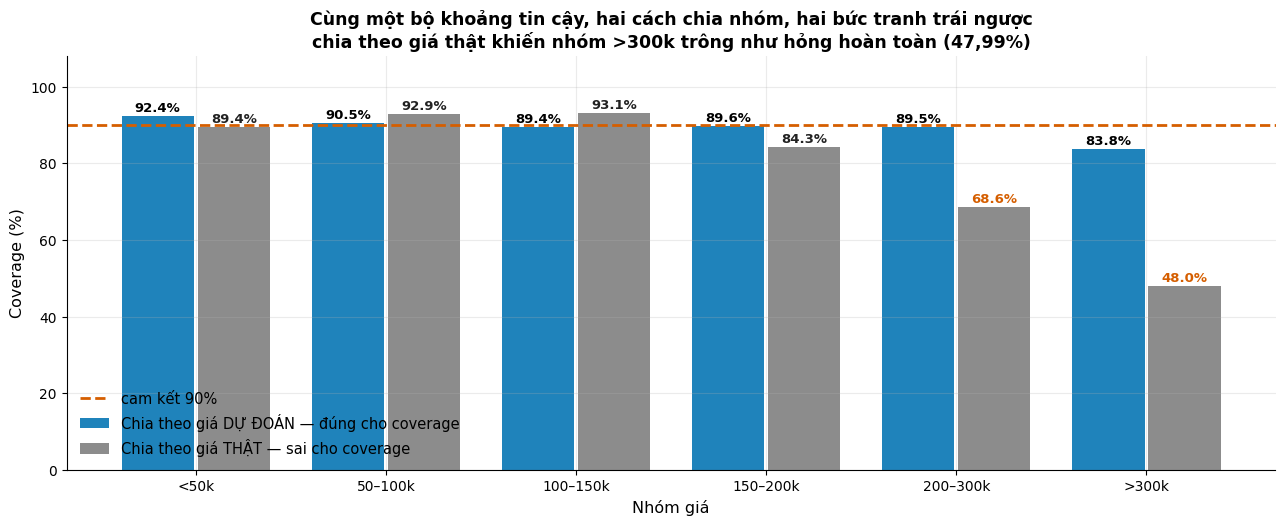


Biên độ coverage giữa các nhóm:
  chia theo giá dự đoán :  8.62 điểm  (thấp nhất 83.79% ở >300k)
  chia theo giá thật    : 45.14 điểm  (thấp nhất 47.99% ở >300k)


In [9]:
# ═════════ HINH NC5 — coverage: hai cach chia cho hai buc tranh ═════════
uc = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
uc = uc[uc.requested_lag_minutes == 5]
q = float(np.quantile((np.abs(uc.hybrid_pred - uc.gia_that)/uc.hybrid_pred).values, .90))
D["trong"] = (D.y >= D.hybrid*(1-q)) & (D.y <= D.hybrid*(1+q))
print(f"Conformal chuẩn hoá toàn cục: nửa độ rộng ±{q:.2%} · coverage tổng {D.trong.mean():.2%}")

cv_pred = D.groupby("theo_hyb",  observed=True).trong.mean().reindex(TEN_GIA)
cv_that = D.groupby("theo_that", observed=True).trong.mean().reindex(TEN_GIA)
n_pred  = D.theo_hyb.value_counts().reindex(TEN_GIA)
n_that  = D.theo_that.value_counts().reindex(TEN_GIA)

fig, ax = plt.subplots(figsize=(13, 5.4))
x = np.arange(len(TEN_GIA))
ax.bar(x-.2, cv_pred*100, .38, color=BLUE,  alpha=.88, label="Chia theo giá DỰ ĐOÁN — đúng cho coverage")
ax.bar(x+.2, cv_that*100, .38, color=MUT,   alpha=.75, label="Chia theo giá THẬT — sai cho coverage")
ax.axhline(90, color=RED, lw=2, ls="--", label="cam kết 90%")
for i in x:
    ax.text(i-.2, cv_pred.iloc[i]*100+1.2, f"{cv_pred.iloc[i]:.1%}", ha="center",
            fontsize=9.5, fontweight="bold")
    ax.text(i+.2, cv_that.iloc[i]*100+1.2, f"{cv_that.iloc[i]:.1%}", ha="center",
            fontsize=9.5, fontweight="bold", color=RED if cv_that.iloc[i] < .8 else INK)
ax.set_xticks(x); ax.set_xticklabels(TEN_GIA)
ax.set_ylim(0, 108); ax.set_ylabel("Coverage (%)"); ax.set_xlabel("Nhóm giá")
ax.legend(frameon=False, loc="lower left")
ax.set_title("Cùng một bộ khoảng tin cậy, hai cách chia nhóm, hai bức tranh trái ngược\n"
             "chia theo giá thật khiến nhóm >300k trông như hỏng hoàn toàn (47,99%)",
             fontweight="bold")
plt.tight_layout(); plt.savefig(HINH/"NC5_coverage_hai_cach_chia.png"); plt.show()

print(f"\nBiên độ coverage giữa các nhóm:")
print(f"  chia theo giá dự đoán : {(cv_pred.max()-cv_pred.min())*100:5.2f} điểm  "
      f"(thấp nhất {cv_pred.min():.2%} ở {cv_pred.idxmin()})")
print(f"  chia theo giá thật    : {(cv_that.max()-cv_that.min())*100:5.2f} điểm  "
      f"(thấp nhất {cv_that.min():.2%} ở {cv_that.idxmin()})")
pd.DataFrame({"coverage theo giá dự đoán": cv_pred, "n dự đoán": n_pred,
              "coverage theo giá thật": cv_that, "n thật": n_that}).to_csv(KQ/"NC_coverage.csv")

### Đọc hình NC5

Cùng một bộ khoảng tin cậy, cùng một tập chuyến:

* Chia theo **giá dự đoán**: coverage dao động 83,8%–92,4%, nhóm `>300k` hụt 6,2 điểm so với cam
  kết. Đây là con số dùng được — nó nói "khi hệ thống báo giá trên 300k thì lời hứa 90% chỉ giữ
  được 83,8%", và Mondrian vá được đúng chỗ đó.
* Chia theo **giá thật**: nhóm `>300k` tụt xuống **47,99%**, nhóm `200–300k` còn 68,6%. Nhìn thì
  như khoảng tin cậy hỏng hoàn toàn, nhưng thực ra không phải — con số này chỉ đang nói lại một
  điều đã biết: những chuyến đắt thật thường bị model đoán hụt, mà đoán hụt thì khoảng dựng quanh
  giá dự đoán tất nhiên không với tới giá thật.

Con số 47,99% **không sai về mặt số học**, nhưng nó trả lời một câu hỏi mà lúc vận hành không ai
hỏi được, vì lúc đó chưa biết giá thật. Dùng nó để hiệu chỉnh khoảng sẽ dẫn tới nới rộng khoảng cho
những chuyến mà hệ thống **không có cách nào nhận ra trước**.

## 6. Kết luận — quy tắc chốt và ảnh hưởng lên tuần 5

### Quy tắc

| Đo cái gì | Chia nhóm theo | Vì sao |
|---|---|---|
| **So sánh model** (MAPE, MAE) | **giá thật** hoặc **quãng đường** | phải là cùng một tập chuyến cho mọi model |
| **Coverage / độ rộng khoảng** | **giá dự đoán** | khoảng là lời hứa đưa ra khi chưa biết giá thật |
| Bất cứ chiều nào có sẵn trước dự báo (giờ, thời tiết, loại xe) | dùng thẳng | không phụ thuộc model |

Nguyên tắc chung đằng sau: **chiều dùng để chia nhóm không được là đại lượng mà chính model sinh
ra**, trừ khi câu hỏi đang hỏi chính là câu hỏi đặt ra tại thời điểm dự báo.

### Ba con số để nhớ

1. Nhóm `>300k` chia theo giá thật có **869** chuyến, chia theo Hybrid dự đoán chỉ còn **327** — và
   chỉ **224** chuyến có mặt ở cả hai (Jaccard 0,23).
2. Lợi thế của GAM ở nhóm giá cao: **+1,65 điểm** khi chia trung lập, **+4,02 điểm** khi để Hybrid
   tự chia nhóm — **phồng 2,4 lần**.
3. Trong mô phỏng với hai model giống hệt nhau, chia nhóm theo dự đoán tạo ra chênh lệch giả
   **±7,2 điểm** và **đảo dấu** tuỳ theo dùng dự đoán của model nào.

### Ảnh hưởng lên các kết quả đang có

Mọi so sánh model trong `tuan_5/` đã dùng nhóm cố định định nghĩa ở ô `NHOM_CO_DINH`, nên **không
phải tính lại**. Riêng các bảng so sánh model theo band giá của tuần 4 thì phải đọc theo phiên bản
đã tính lại trong `RESEARCH_PAPER` §6.5, không dùng bản gốc.

Riêng notebook `04_MONDRIAN_QUANG_DUONG` chia nhóm theo giá **dự đoán** — đó là ngoại lệ có chủ ý,
đúng theo §5 ở trên, không phải chỗ sót.